## Composite analysis for model output

### Import package

In [1]:
import h5py
import numpy as np

from typing import cast, Dict
from pathlib import Path

from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import TwoSlopeNorm

### Composite for NoRad experiment

#### Load NoRad experiments

In [2]:
# input directory
input_dir: Path = Path("/work/b11209013/Kuang2008_v0.5.0/full")

# ignore the first n (default: 20 days) for composite
skip_days: np.intp = np.intp(20)

# load NoRad data
with h5py.File(input_dir / "NoRad/GalerkinState.h5", "r") as norad_ds:

    # coordinates
    coords: Dict[str, np.ndarray] = {
        key: cast(h5py.Dataset, norad_ds[key])[...]
        for key in ["x", "z"]
    }

    norad_variables: Dict[str, np.ndarray] = {
        key: cast(h5py.Dataset, norad_ds[key])[..., skip_days:, :]
        for key in ["J1", "J2", "w1", "w2", "T1", "T2"]
    } # shape: (nz, nx, nt, nens)

NZ, NX, NT, NENS = norad_variables["J1"].shape

#### Add the first and second mode

In [3]:
norad_field: Dict[str, np.ndarray] = {
    key: norad_variables[f"{key}1"] + norad_variables[f"{key}2"]
    for key in ["J", "w", "T"]
}

del norad_variables

#### Calculate covariance between convective heating and temperature perturbations

In [4]:
Γ_d: float = 9.81 / 1004.5
Γ: float = 0.0065
T_bar = 300 - Γ * coords["z"]

norad_field["source"] = norad_field["J"] * norad_field["T"] / T_bar[:, None, None, None] * (Γ_d) / (Γ_d - Γ)

#### Centering profiles for different variables

In [5]:
# defining the center
x_half: np.intp = np.intp(NX//2)

# use vertically averaged convective heating as 
# a proxy of convection parameterization
J_vavg: np.ndarray = np.nanmean(norad_field["J"], axis=0)

# find maximum of the vertically averaged convective heating
# and calculate shifting
J_vavg_max: np.ndarray = np.nanargmax(J_vavg, axis=0)

# calculate shifts
shifts: np.ndarray = x_half - J_vavg_max

# roll maximum to the center
def _multi_axis_rolling(
        data  : np.ndarray,
        shifts: np.ndarray,
) -> np.ndarray:
    nt, nens = shifts.shape

    # rolling along time and ensemble axis
    tmp_all_rolling: list = []

    for j in range(nt):
        tmp_ens_rolling: list = [] 

        for i in range(nens):
            tmp_ens_rolling.append(
                np.roll(
                    data[:, :, j, i],
                    shift = shifts[j, i],
                    axis=1
                )
            )

        tmp_all_rolling.append(np.array(tmp_ens_rolling))

    return np.array(tmp_all_rolling)

norad_rolled_field: Dict[str, np.ndarray] = {
    key: _multi_axis_rolling(value, shifts=shifts)
    for (key,value) in norad_field.items()
}

# mean over time and ensembles
norad_composite: Dict[str, np.ndarray] = {
    key: np.nanmean(values, axis=(0, 1))
    for (key, values) in norad_rolled_field.items()
}

#### Visualizing the composite profiles

##### Setup coordinates

In [6]:
# Shared style, matching the ERA5 composite notebook.
FIGURE_DIR = Path("/home/b11209013/Manuscript_Prep/KW_CRI/Figure/model_composite")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
NORAD_DIR = FIGURE_DIR / "NoRad"
NORAD_DIR.mkdir(parents=True, exist_ok=True)

LONGITUDE_LIMIT = 50.0

# The rolling step places the convective center at NX // 2.
metres_per_degree = 2 * np.pi * 6.371e6 / 360.0
x_rel = (coords["x"] - coords["x"][NX // 2]) / metres_per_degree
height_km = coords["z"] / 1000.0
visible = np.abs(x_rel) <= LONGITUDE_LIMIT

##### assisting functions

In [7]:
def _remove_zero_contour(
        data: np.ndarray
) -> np.ndarray:

    total_level = MaxNLocator(nbins=8).tick_values(
        np.nanmin(data), np.nanmax(data),
        )

    total_level = np.asarray(
        MaxNLocator(nbins=8).tick_values(
            np.nanmin(data),
            np.nanmax(data),
        ),
        dtype=float,
    )
    return total_level[~np.isclose(total_level, 0.0)]

##### Visualize w vs. J profiles

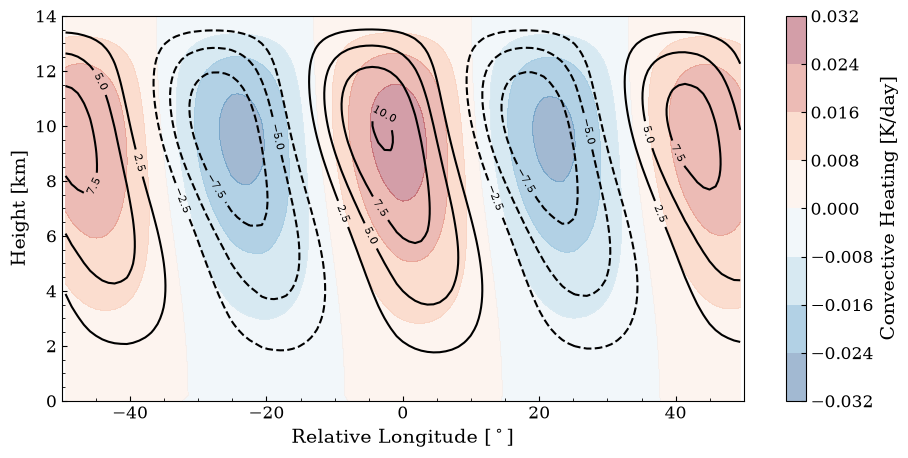

In [8]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "legend.fontsize": 12,
    "figure.titlesize": 18,
    "contour.negative_linestyle": "dashed",
})

fig, ax = plt.subplots(1, 1, figsize=(11, 5))

J_ctf = ax.contourf(
    x_rel[visible], height_km, norad_composite["J"][:, visible],
    cmap="RdBu_r", norm=TwoSlopeNorm(0.0), alpha=0.4,
)
# Keep automatically spaced contour levels, excluding zero.
w_ct = ax.contour(
    x_rel[visible], height_km, norad_composite["w"][:, visible],
    levels=_remove_zero_contour(norad_composite["w"][:, visible]),
    colors="k"
)
ax.minorticks_on()
ax.tick_params(direction="in")
ax.set_xlim(-50, 50)
ax.set_xlabel(r"Relative Longitude [$^\circ$]")
ax.set_ylabel("Height [km]")
plt.colorbar(J_ctf, ax=ax, label="Convective Heating [K/day]")
plt.clabel(w_ct, inline=True, fontsize=8)
plt.savefig(NORAD_DIR / "wJ_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

##### Visualizing the T vs. J

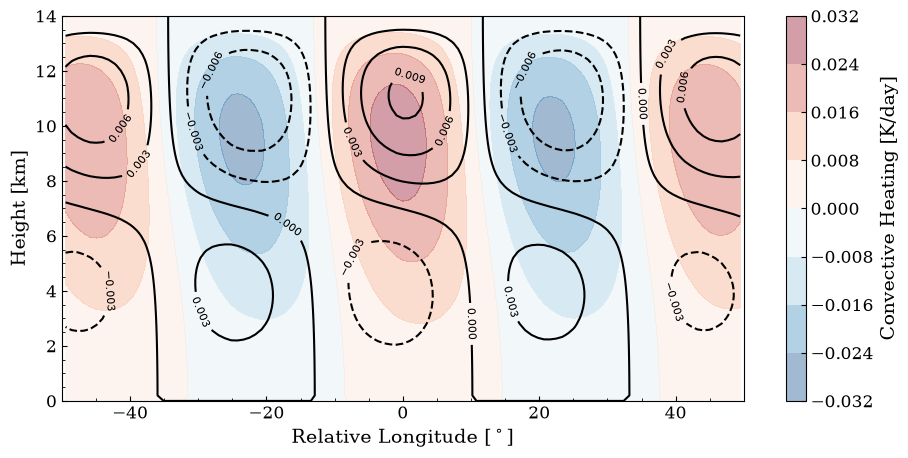

In [9]:

fig, ax = plt.subplots(1, 1, figsize=(11, 5))

J_ctf = ax.contourf(
    x_rel[visible], height_km, norad_composite["J"][:, visible],
    cmap="RdBu_r", norm=TwoSlopeNorm(0.0), alpha=0.4,
)
# Keep automatically spaced contour levels, excluding zero.
w_ct = ax.contour(
    x_rel[visible], height_km, norad_composite["T"][:, visible],
    levels=6,
    colors="k"
)
ax.minorticks_on()
ax.tick_params(direction="in")
ax.set_xlim(-50, 50)
ax.set_xlabel(r"Relative Longitude [$^\circ$]")
ax.set_ylabel("Height [km]")
plt.colorbar(J_ctf, ax=ax, label="Convective Heating [K/day]")
plt.clabel(w_ct, inline=True, fontsize=8)
plt.savefig(NORAD_DIR / "TJ_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

##### Visualizing EAPE generation

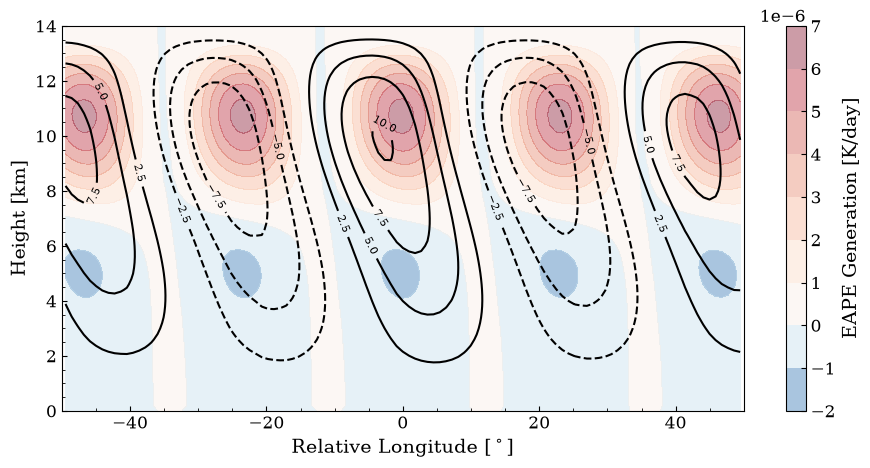

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(11, 5))

J_ctf = ax.contourf(
    x_rel[visible], height_km, norad_composite["source"][:, visible],
    cmap="RdBu_r", norm=TwoSlopeNorm(0.0), alpha=0.4,
)
# Keep automatically spaced contour levels, excluding zero.
w_ct = ax.contour(
    x_rel[visible], height_km, norad_composite["w"][:, visible],
    levels=_remove_zero_contour(norad_composite["w"][:, visible]),
    colors="k"
)
ax.minorticks_on()
ax.tick_params(direction="in")
ax.set_xlim(-50, 50)
ax.set_xlabel(r"Relative Longitude [$^\circ$]")
ax.set_ylabel("Height [km]")
plt.colorbar(J_ctf, ax=ax, label="EAPE Generation [K/day]")
plt.clabel(w_ct, inline=True, fontsize=8)
plt.savefig(NORAD_DIR / "EAPE_gen_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

### Composite for CldRad experiment

#### Load CldRad experiments

In [11]:
# load CldRad data
with h5py.File(input_dir / "CldRad/GalerkinState.h5", "r") as cldrad_ds:

    # coordinates
    cldrad_coords: Dict[str, np.ndarray] = {
        key: cast(h5py.Dataset, cldrad_ds[key])[...]
        for key in ["x", "z"]
    }

    cldrad_variables: Dict[str, np.ndarray] = {
        key: cast(h5py.Dataset, cldrad_ds[key])[..., skip_days:, :]
        for key in ["J1", "J2", "w1", "w2", "T1", "T2"]
    } # shape: (nz, nx, nt, nens)

CLDRAD_NZ, CLDRAD_NX, CLDRAD_NT, CLDRAD_NENS = cldrad_variables["J1"].shape

#### Add the first and second mode

In [12]:
cldrad_field: Dict[str, np.ndarray] = {
    key: cldrad_variables[f"{key}1"] + cldrad_variables[f"{key}2"]
    for key in ["J", "w", "T"]
}

del cldrad_variables

#### Calculate covariance between convective heating and temperature perturbations

In [13]:
cldrad_field["source"] = cldrad_field["J"] * cldrad_field["T"] / T_bar[:, None, None, None] * (Γ_d) / (Γ_d - Γ)

#### Centering profiles for different variables

In [14]:
# defining the center
cldrad_x_half: np.intp = np.intp(CLDRAD_NX//2)

# use vertically averaged convective heating as 
# a proxy of convection parameterization
cldrad_J_vavg: np.ndarray = np.nanmean(cldrad_field["J"], axis=0)

# find maximum of the vertically averaged convective heating
# and calculate shifting
cldrad_J_vavg_max: np.ndarray = np.nanargmax(cldrad_J_vavg, axis=0)

# calculate shifts
cldrad_shifts: np.ndarray = cldrad_x_half - cldrad_J_vavg_max

# Use the same rolling helper as the NoRad composite.
cldrad_rolled_field: Dict[str, np.ndarray] = {
    key: _multi_axis_rolling(value, shifts=cldrad_shifts)
    for (key,value) in cldrad_field.items()
}

# mean over time and ensembles
cldrad_composite: Dict[str, np.ndarray] = {
    key: np.nanmean(values, axis=(0, 1))
    for (key, values) in cldrad_rolled_field.items()
}

#### Visualizing the composite profiles

##### Setup coordinates

In [15]:
CLDRAD_DIR = FIGURE_DIR / "CldRad"
CLDRAD_DIR.mkdir(parents=True, exist_ok=True)

# The rolling step places the convective center at CLDRAD_NX // 2.
cldrad_x_rel = (cldrad_coords["x"] - cldrad_coords["x"][CLDRAD_NX // 2]) / metres_per_degree
cldrad_height_km = cldrad_coords["z"] / 1000.0
cldrad_visible = np.abs(cldrad_x_rel) <= LONGITUDE_LIMIT

##### Visualize w vs. J profiles

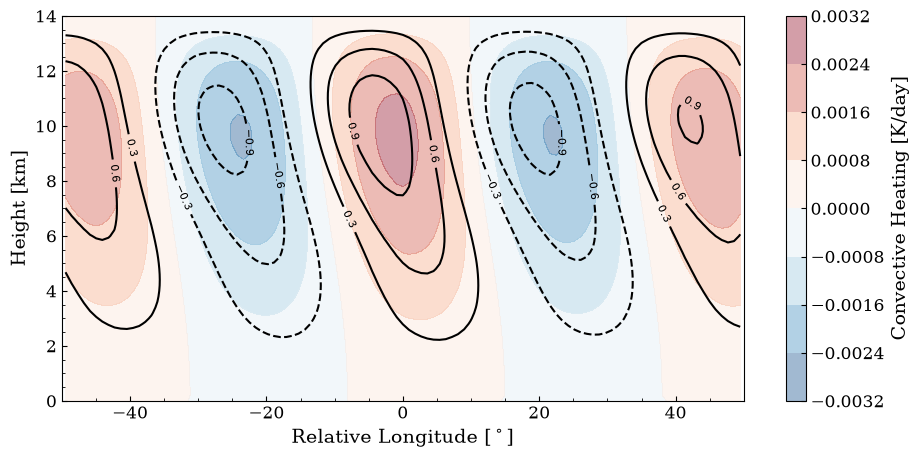

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(11, 5))

J_ctf = ax.contourf(
    cldrad_x_rel[cldrad_visible], cldrad_height_km, cldrad_composite["J"][:, cldrad_visible],
    cmap="RdBu_r", norm=TwoSlopeNorm(0.0), alpha=0.4,
)
# Keep automatically spaced contour levels, excluding zero.
w_ct = ax.contour(
    cldrad_x_rel[cldrad_visible], cldrad_height_km, cldrad_composite["w"][:, cldrad_visible],
    levels=_remove_zero_contour(cldrad_composite["w"][:, cldrad_visible]),
    colors="k"
)
ax.minorticks_on()
ax.tick_params(direction="in")
ax.set_xlim(-50, 50)
ax.set_xlabel(r"Relative Longitude [$^\circ$]")
ax.set_ylabel("Height [km]")
plt.colorbar(J_ctf, ax=ax, label="Convective Heating [K/day]")
plt.clabel(w_ct, inline=True, fontsize=8)
plt.savefig(CLDRAD_DIR / "wJ_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

##### Visualizing the T vs. J

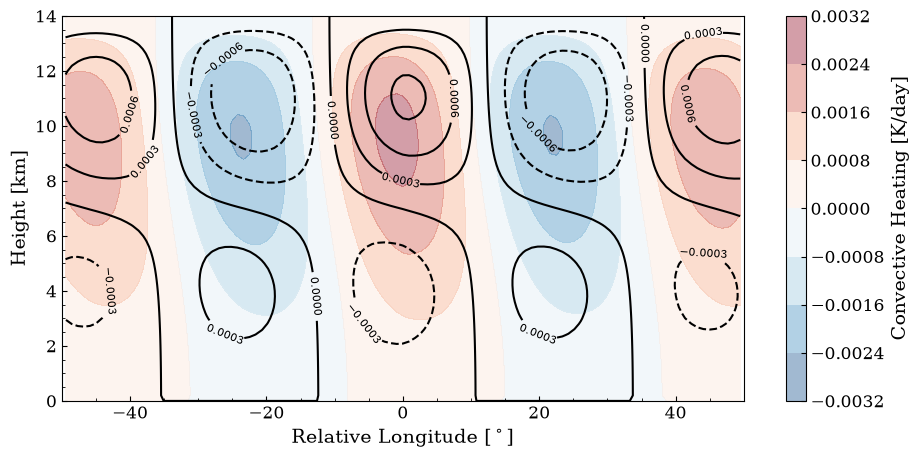

In [17]:

fig, ax = plt.subplots(1, 1, figsize=(11, 5))

J_ctf = ax.contourf(
    cldrad_x_rel[cldrad_visible], cldrad_height_km, cldrad_composite["J"][:, cldrad_visible],
    cmap="RdBu_r", norm=TwoSlopeNorm(0.0), alpha=0.4,
)
# Keep automatically spaced contour levels, excluding zero.
w_ct = ax.contour(
    cldrad_x_rel[cldrad_visible], cldrad_height_km, cldrad_composite["T"][:, cldrad_visible],
    levels=6,
    colors="k"
)
ax.minorticks_on()
ax.tick_params(direction="in")
ax.set_xlim(-50, 50)
ax.set_xlabel(r"Relative Longitude [$^\circ$]")
ax.set_ylabel("Height [km]")
plt.clabel(w_ct, inline=True, fontsize=8)
plt.colorbar(J_ctf, ax=ax, label="Convective Heating [K/day]")
plt.savefig(CLDRAD_DIR / "TJ_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

##### Visualizing EAPE generation

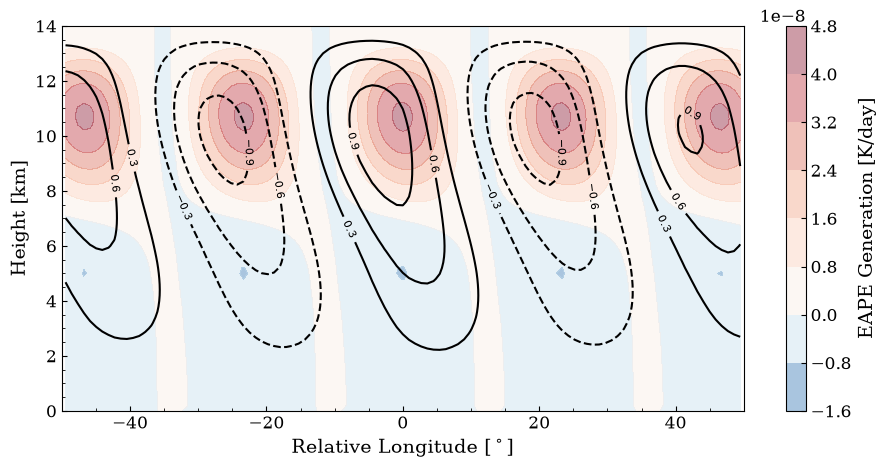

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(11, 5))

J_ctf = ax.contourf(
    x_rel[visible], height_km, cldrad_composite["source"][:, visible],
    cmap="RdBu_r", norm=TwoSlopeNorm(0.0), alpha=0.4,
)
# Keep automatically spaced contour levels, excluding zero.
w_ct = ax.contour(
    x_rel[visible], height_km, cldrad_composite["w"][:, visible],
    levels=_remove_zero_contour(cldrad_composite["w"][:, visible]),
    colors="k"
)
ax.minorticks_on()
ax.tick_params(direction="in")
ax.set_xlim(-50, 50)
ax.set_xlabel(r"Relative Longitude [$^\circ$]")
ax.set_ylabel("Height [km]")
plt.colorbar(J_ctf, ax=ax, label="EAPE Generation [K/day]")
plt.clabel(w_ct, inline=True, fontsize=8)
plt.savefig(CLDRAD_DIR / "EAPE_gen_composite.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)